<a href="https://colab.research.google.com/github/hanadialharbi/Deepfake-Detection-Master-Project/blob/main/Copy_of_deepfake_detection_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive and define dataset paths for real and fake video samples

from google.colab import drive
drive.mount('/content/drive')

ROOT = "/content/drive/MyDrive/videos"
VIDEO_DIR_REAL = f"{ROOT}/real"
VIDEO_DIR_FAKE = f"{ROOT}/fake"


Mounted at /content/drive


In [ ]:


import os, cv2, numpy as np, torch, torch.nn as nn
from glob import glob
from skimage.feature import local_binary_pattern


VIDEO_DIR_REAL = os.path.join(ROOT, "real")
VIDEO_DIR_FAKE = os.path.join(ROOT, "fake")
CACHE_DIR = os.path.join(ROOT, "cnn_feature_cache_31_v1")

os.makedirs(CACHE_DIR, exist_ok=True)

# ================== CONFIG ==================
NUM_FRAMES = 32
IMG_SIZE = 112
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# ================== FACE DETECTOR (FOR RATIO ONLY) ==================
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# ================== FRAME EXTRACTION ==================
def extract_frames(video_path, num_frames=NUM_FRAMES, size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        return None

    idxs = np.linspace(0, total - 1, num_frames).astype(int)
    frames = []

    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ret, frame = cap.read()
        if not ret:
            continue

        h, w, _ = frame.shape
        s = min(h, w)
        y0 = (h - s) // 2
        x0 = (w - s) // 2

        frame = frame[y0:y0+s, x0:x0+s]
        frame = cv2.resize(frame, (size, size))
        frame = frame[:, :, ::-1] / 255.0
        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32) if len(frames) == num_frames else None

# ================== OPTICAL FLOW ==================
def compute_optical_flow(frames):
    mags = []
    for i in range(len(frames) - 1):
        prev = cv2.cvtColor((frames[i] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        nxt  = cv2.cvtColor((frames[i+1] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prev, nxt, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        mags.append(np.mean(mag))
    return np.array(mags, dtype=np.float32)

# ================== FORENSIC FEATURES ==================
def fft_variance(frame):
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    f = np.fft.fftshift(np.fft.fft2(gray))
    mag = np.log(np.abs(f) + 1e-8)
    return np.var(mag)

def lbp_hist(frame, P=8, R=1):
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    hist, _ = np.histogram(lbp, bins=np.arange(0, P + 3), density=True)
    return hist

def blur_metric(frame):
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def face_area_ratio(frame):
    gray = cv2.cvtColor((frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    faces = face_detector.detectMultiScale(gray, 1.1, 5)
    if len(faces) == 0:
        return 0.0
    areas = [w * h for (_, _, w, h) in faces]
    return np.mean(areas) / (gray.shape[0] * gray.shape[1])

# ================== CNN ENCODER ==================
class CNN_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        return self.net(x).squeeze(-1).squeeze(-1)

cnn = CNN_Encoder().to(DEVICE).eval()
torch.save(cnn.state_dict(), "cnn_encoder.pth")

# ================== CACHE FUNCTION ==================
@torch.no_grad()
def cache_video(video_path, label):
    base = os.path.basename(video_path).replace(".mp4", "")
    out_path = os.path.join(CACHE_DIR, f"{label}_{base}.npz")

    if os.path.exists(out_path):
        return True

    frames = extract_frames(video_path)
    if frames is None:
        return False

    # CNN
    frames_t = torch.tensor(frames).permute(0, 3, 1, 2).to(DEVICE)
    cnn_feats = cnn(frames_t).cpu().numpy()

    # Temporal deltas
    delta_rgb = np.mean(np.abs(frames[1:] - frames[:-1]), axis=(1,2,3))
    delta_cnn = np.linalg.norm(cnn_feats[1:] - cnn_feats[:-1], axis=1)
    flow_mag  = compute_optical_flow(frames)

    # Forensic features (per-frame)
    fft_vals   = np.array([fft_variance(f) for f in frames])
    blur_vals  = np.array([blur_metric(f) for f in frames])
    face_ratio = np.array([face_area_ratio(f) for f in frames])
    lbp_feats  = np.array([lbp_hist(f) for f in frames])

    np.savez(
        out_path,
        cnn_feats=cnn_feats,
        delta_rgb=delta_rgb,
        delta_cnn=delta_cnn,
        flow_mag=flow_mag,
        fft_mean=np.mean(fft_vals),
        fft_std=np.std(fft_vals),
        blur_mean=np.mean(blur_vals),
        blur_std=np.std(blur_vals),
        face_ratio_mean=np.mean(face_ratio),
        face_ratio_std=np.std(face_ratio),
        lbp_mean=np.mean(lbp_feats, axis=0)
    )

    return True

# ================== RUN ==================
real_videos = glob(os.path.join(VIDEO_DIR_REAL, "*.mp4"))
fake_videos = glob(os.path.join(VIDEO_DIR_FAKE, "*.mp4"))

print(f"Caching {len(real_videos)} REAL + {len(fake_videos)} FAKE videos")

ok = 0
for v in real_videos:
    ok += int(cache_video(v, "real"))

for v in fake_videos:
    ok += int(cache_video(v, "fake"))

print(f"✅ Cached videos: {ok}/{len(real_videos) + len(fake_videos)}")
print("Cache directory:", CACHE_DIR)


DEVICE: cpu
Loaded: 128 samples
Class distribution: [46 82]
After SMOTE: [82 82]
X_tab_sm: (164, 237) | y_sm: 164
X_seq_sm: 164 | aligned with y_sm: 164

========== FOLD 1/5 ==========

  >> Model: CNN1D+TCN
Saved model: CNN1D+TCN

  >> Model: COANet-Lite
Saved model: COANet-Lite

  >> Model: CNN+Transformer
Saved model: CNN+Transformer

========== FOLD 2/5 ==========

  >> Model: CNN1D+TCN
Saved model: CNN1D+TCN

  >> Model: COANet-Lite
Saved model: COANet-Lite

  >> Model: CNN+Transformer
Saved model: CNN+Transformer

========== FOLD 3/5 ==========

  >> Model: CNN1D+TCN
Saved model: CNN1D+TCN

  >> Model: COANet-Lite
Saved model: COANet-Lite

  >> Model: CNN+Transformer
Saved model: CNN+Transformer

========== FOLD 4/5 ==========

  >> Model: CNN1D+TCN
Saved model: CNN1D+TCN

  >> Model: COANet-Lite
Saved model: COANet-Lite

  >> Model: CNN+Transformer
Saved model: CNN+Transformer

========== FOLD 5/5 ==========

  >> Model: CNN1D+TCN
Saved model: CNN1D+TCN

  >> Model: COANet-Lite


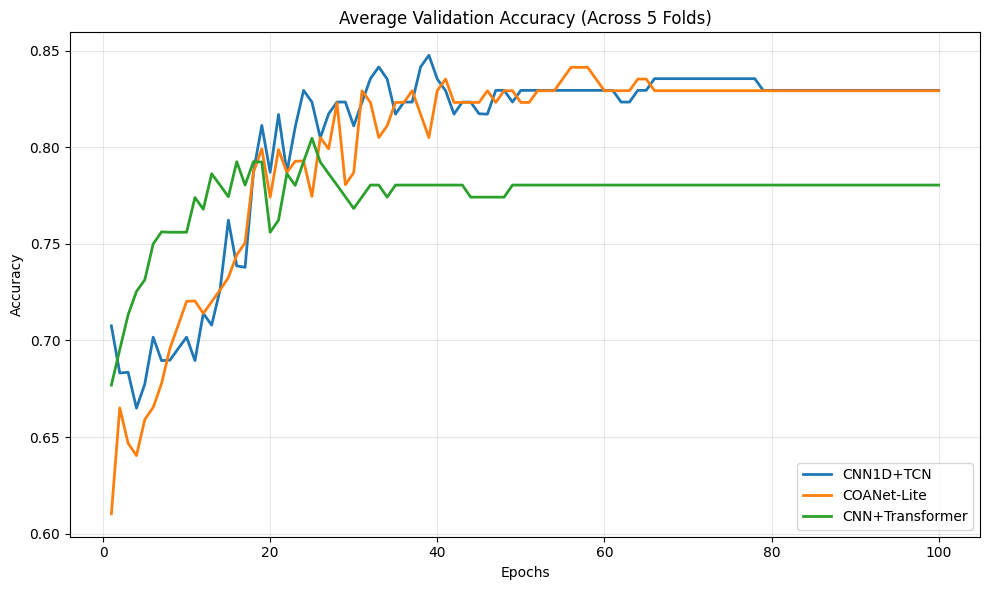

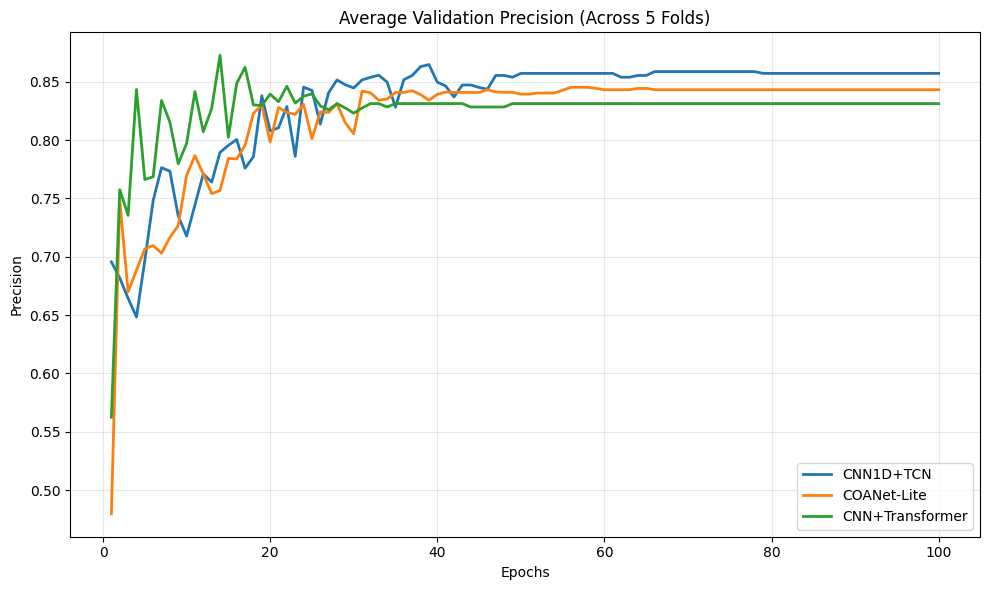

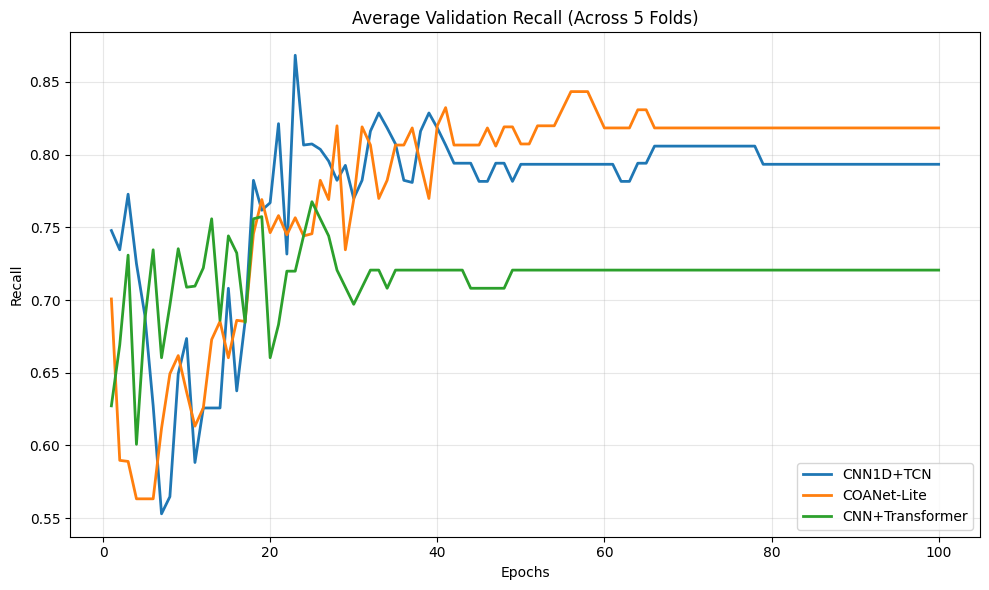

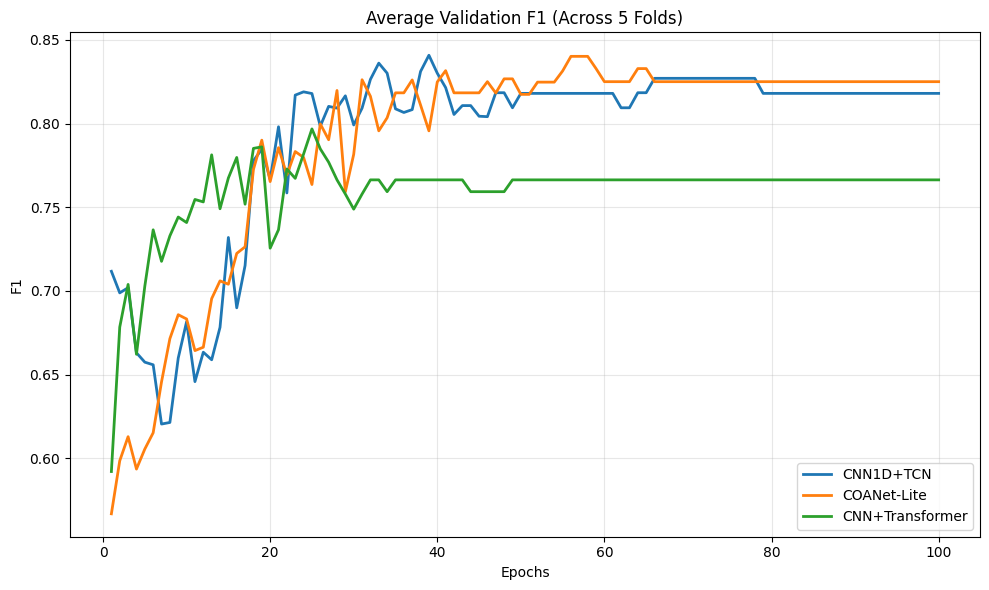

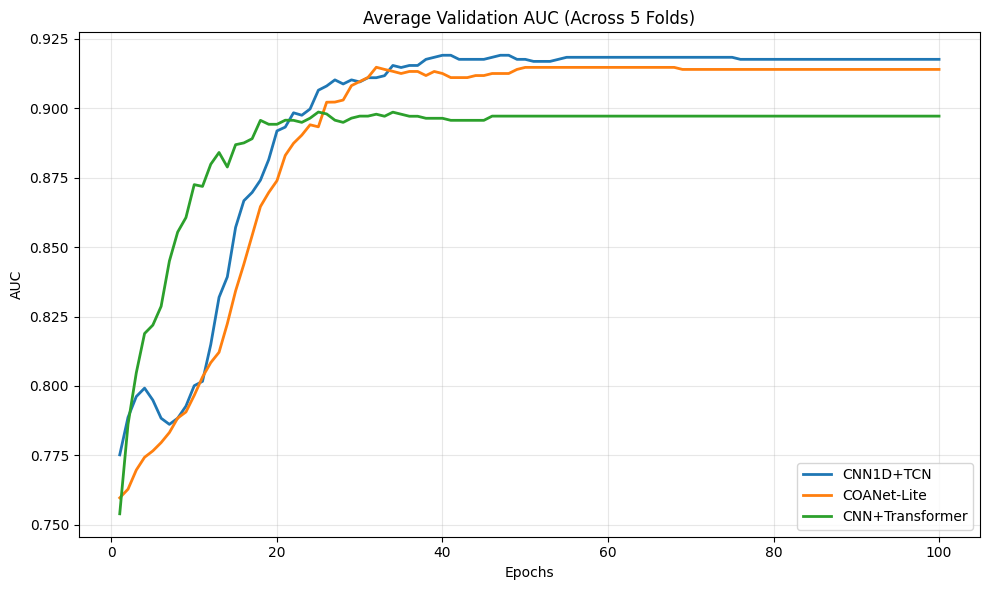


================ FINAL COMPARISON (OOF) ================

                 Accuracy  Precision  Recall     F1    AUC
CNN1D+TCN           0.829      0.855   0.793  0.823  0.908
COANet-Lite         0.829      0.838   0.817  0.827  0.907
CNN+Transformer     0.780      0.819   0.720  0.766  0.893

Generating plots...


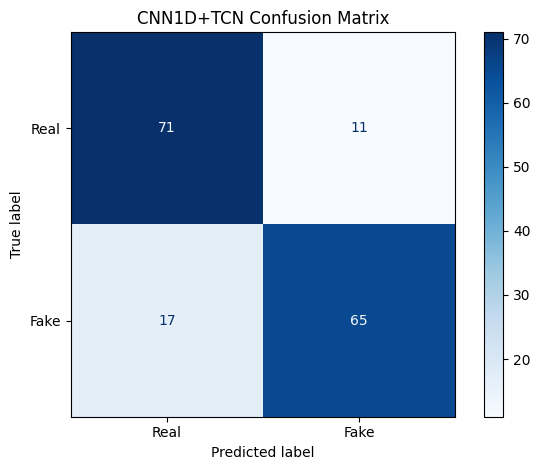

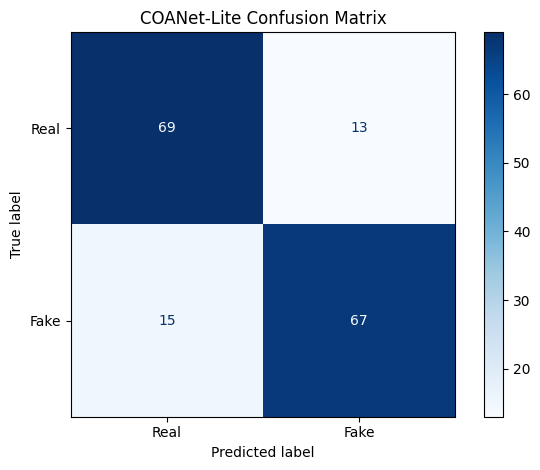

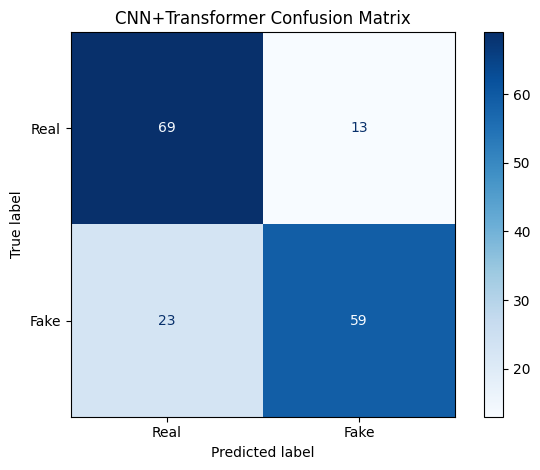

<Figure size 1400x600 with 0 Axes>

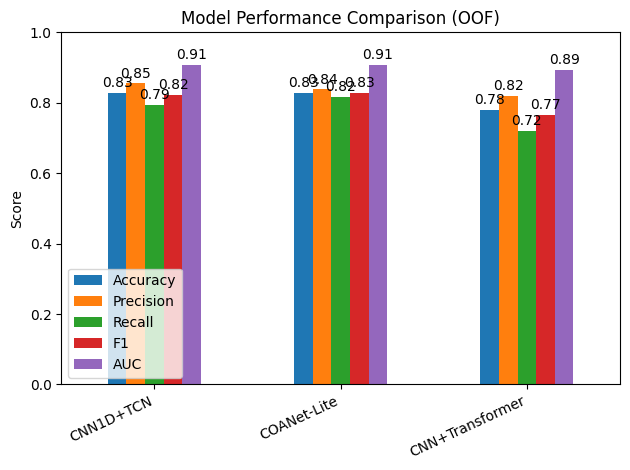

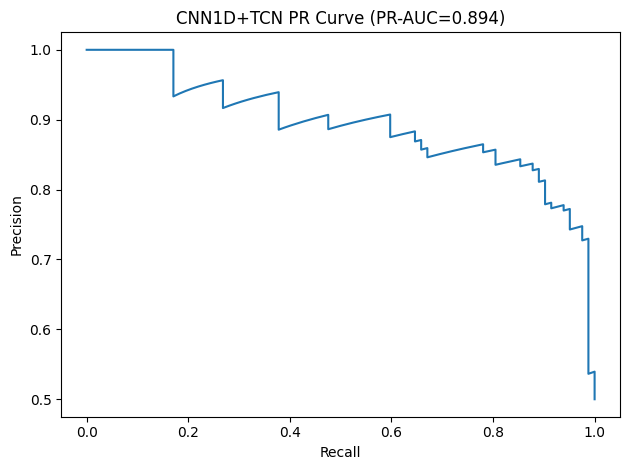

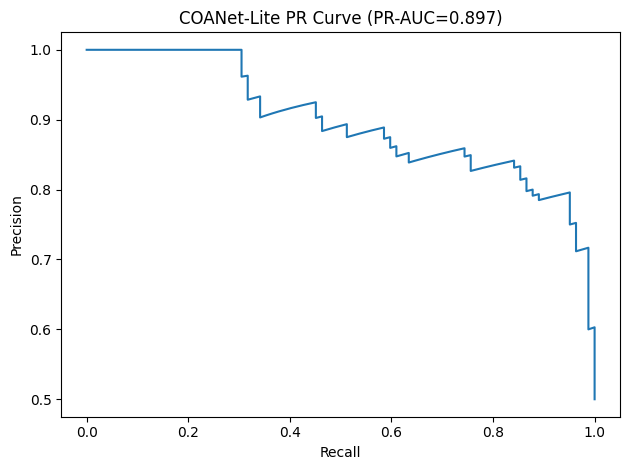

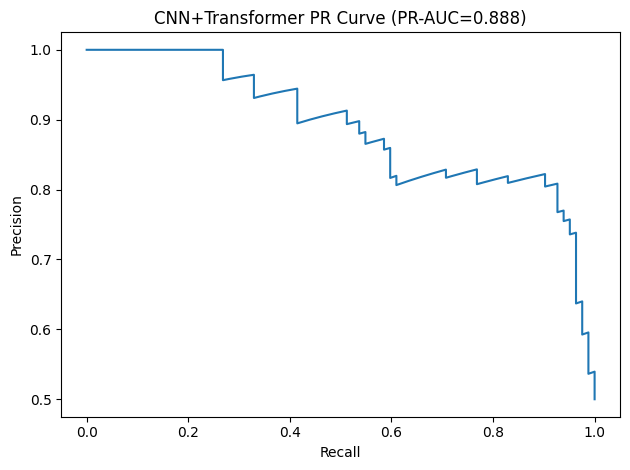

✅ All plots saved.


In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE

# -------------------------------
# DEVICE
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------------
# PATHS
# -------------------------------
ROOT = "/content/drive/MyDrive/videos"
DATA_DIR = os.path.join(ROOT, "cnn_feature_cache_31_v1")

# -------------------------------
# CONFIG
# -------------------------------
FOLDS = 5
SEED = 42
EPOCHS = 100
BATCH_SIZE = 32
LR = 3e-4
TAB_OUT = 64
DROPOUT = 0.2

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# LOAD DATA (TABULAR + TEMPORAL)
# ============================================================
X_tab, X_seq, y = [], [], []

for fname in os.listdir(DATA_DIR):
    if not fname.endswith(".npz"):
        continue

    label = 1 if fname.lower().startswith("fake_") else 0

    with np.load(os.path.join(DATA_DIR, fname)) as d:
        seq = d["cnn_feats"]  # (T, D)
        X_seq.append(seq)

        feats = [
            seq.mean(0).reshape(-1),
            seq.std(0).reshape(-1),
            *[np.atleast_1d(d[k]).reshape(-1) for k in [
                "delta_rgb","delta_cnn","flow_mag",
                "fft_mean","fft_std","blur_mean","blur_std",
                "face_ratio_mean","face_ratio_std","lbp_mean"
            ]]
        ]
        X_tab.append(np.concatenate(feats))
        y.append(label)

X_tab = np.array(X_tab)
y = np.array(y)

print("Loaded:", len(y), "samples")
print("Class distribution:", np.bincount(y))

# ============================================================
# VISUALIZATION UTILITIES
# ============================================================
def plot_confusion(y_true, y_pred, title, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(name, dpi=200)
    plt.show()
    plt.close()

def plot_bar_comparison(results_df, filename="bar_metrics_comparison.png"):
    plt.figure(figsize=(14,6))
    ax = results_df.plot(kind="bar")
    plt.title("Model Performance Comparison (OOF)")
    plt.ylabel("Score")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0,1)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()



def plot_pr_curve(y_true, prob_scores, title, filename):
    precision, recall, _ = precision_recall_curve(y_true, prob_scores)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (PR-AUC={pr_auc:.3f})")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()


def plot_average_metrics(all_histories, metric_name, filename):

    plt.figure(figsize=(10, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for (model_name, folds_data), color in zip(all_histories.items(), colors):
        data       = np.array(folds_data)           # (n_folds, EPOCHS)
        mean_vals  = np.mean(data, axis=0)
        std_vals   = np.std(data,  axis=0)
        epochs_range = range(1, len(mean_vals) + 1)

        plt.plot(epochs_range, mean_vals,
                 label=f"{model_name}", color=color, lw=2)


    plt.title(f"Average Validation {metric_name} (Across {FOLDS} Folds)")
    plt.xlabel("Epochs")
    plt.ylabel(metric_name)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()

# ============================================================
# PREPROCESSING
# ============================================================
scaler = StandardScaler()
X_tab_scaled = scaler.fit_transform(X_tab)

sm = SMOTE(random_state=SEED)
X_tab_sm, y_sm = sm.fit_resample(X_tab_scaled, y)

print("After SMOTE:", np.bincount(y_sm))
print("X_tab_sm:", X_tab_sm.shape, "| y_sm:", len(y_sm))

# Build X_seq_sm aligned to SMOTE result
orig_n = len(X_seq)
target_n = len(y_sm)

X_seq_sm = list(X_seq)
if target_n > orig_n:
    y_orig = np.array(y)
    minority = 0 if np.sum(y_orig==0) < np.sum(y_orig==1) else 1
    minority_idx = np.where(y_orig==minority)[0]
    if len(minority_idx) == 0:
        minority_idx = np.arange(orig_n)
    extra = target_n - orig_n
    extra_idx = np.random.choice(minority_idx, size=extra, replace=True)
    for i in extra_idx:
        X_seq_sm.append(X_seq[i])

X_seq_sm = X_seq_sm[:target_n]
print("X_seq_sm:", len(X_seq_sm), "| aligned with y_sm:", len(y_sm))


class HybridDataset(Dataset):
    def __init__(self, X_seq_list, X_tab_arr, y_arr, normalize_seq=True):
        self.X_seq = X_seq_list
        self.X_tab = X_tab_arr
        self.y = y_arr
        self.normalize_seq = normalize_seq

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = torch.tensor(self.X_seq[idx], dtype=torch.float32)
        if self.normalize_seq:
            seq = (seq - seq.mean(dim=0, keepdim=True)) / (seq.std(dim=0, keepdim=True) + 1e-6)
        tab = torch.tensor(self.X_tab[idx], dtype=torch.float32)
        y   = torch.tensor(self.y[idx], dtype=torch.long)
        return seq, tab, y


# ============================================================
# MODEL COMPONENTS
# ============================================================
class TabMLP(nn.Module):
    def __init__(self, tab_dim, out_dim=64, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(tab_dim, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, out_dim), nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


class HybridHead(nn.Module):
    def __init__(self, in_dim, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)


class TemporalCNNTransformer_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(nn.Conv1d(dim, hid, 3, padding=1), nn.ReLU())
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hid, nhead=2, dim_feedforward=hid*2, dropout=0.2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.attn = nn.Linear(hid, 1)
        self.out_dim = hid

    def forward(self, seq):
        x = self.cnn(seq.transpose(1,2)).transpose(1,2)
        x = self.transformer(x)
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


class TemporalCNNBiLSTMAttention_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(dim, hid, 3, padding=1), nn.ReLU(),
            nn.Conv1d(hid, hid, 3, padding=1), nn.ReLU()
        )
        self.lstm = nn.LSTM(hid, hid, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hid*2, 1)
        self.out_dim = hid*2

    def forward(self, seq):
        x = self.cnn(seq.transpose(1,2)).transpose(1,2)
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        return (lstm_out * attn_weights).sum(dim=1)


class TemporalCNNTCN_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(nn.Conv1d(dim, hid, 3, padding=1), nn.ReLU())
        self.tcn = nn.Sequential(
            nn.Conv1d(hid, hid, 3, padding=1, dilation=1), nn.ReLU(),
            nn.Conv1d(hid, hid, 3, padding=2, dilation=2), nn.ReLU()
        )
        self.out_dim = hid

    def forward(self, seq):
        x = self.cnn(seq.transpose(1,2))
        return self.tcn(x).mean(-1)


class HybridModel(nn.Module):
    def __init__(self, temporal_backbone, tab_dim, tab_out=64, drop=0.2):
        super().__init__()
        self.temporal = temporal_backbone
        self.mlp  = TabMLP(tab_dim, out_dim=tab_out, drop=drop)
        self.head = HybridHead(self.temporal.out_dim + tab_out, drop=drop)

    def forward(self, seq, tab):
        return self.head(torch.cat([self.temporal(seq), self.mlp(tab)], dim=1))


class COANetLite(nn.Module):
    def __init__(self, dim, tab_dim, hidden=128, drop=0.2):
        super().__init__()
        self.temp = nn.Sequential(
            nn.Conv1d(dim, hidden, 3, padding=1, dilation=1), nn.ReLU(),
            nn.Dropout(drop),
            nn.Conv1d(hidden, hidden, 3, padding=2, dilation=2), nn.ReLU()
        )
        self.forensic = nn.Sequential(
            nn.Linear(tab_dim, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 64), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(hidden+64, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 2)
        )

    def forward(self, seq, tab):
        h_t = self.temp(seq.transpose(1,2)).mean(-1)
        h_f = self.forensic(tab)
        return self.head(torch.cat([h_t, h_f], dim=1))


# ============================================================
# TRAIN / PREDICT / METRICS
# ============================================================
def predict_probs(model, val_loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for seq, tab, _ in val_loader:
            seq, tab = seq.to(DEVICE), tab.to(DEVICE)
            p = torch.softmax(model(seq, tab), 1)[:,1].detach().cpu().numpy()
            probs.extend(p)
    return np.array(probs)


def calc_metrics(y_true, probs, thr=0.5):
    preds = (probs >= thr).astype(int)
    return {
        "Accuracy":  accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall":    recall_score(y_true, preds, zero_division=0),
        "F1":        f1_score(y_true, preds, zero_division=0),
        "AUC":       roc_auc_score(y_true, probs)
    }, preds


def train_one_model(model, train_loader, val_loader, epochs=100, lr=3e-4):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    y_np = np.array(train_loader.dataset.y)
    classes, counts = np.unique(y_np, return_counts=True)
    w = counts.sum() / (len(classes) * counts)
    class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=5)

    train_losses = []
    val_losses   = []
    epoch_metrics = {m: [] for m in ["Accuracy","Precision","Recall","F1","AUC"]}

    for ep in range(epochs):
        model.train()
        ep_train_loss = 0.0
        for seq, tab, yb in train_loader:
            seq, tab, yb = seq.to(DEVICE), tab.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(seq, tab), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_train_loss += loss.item()
        ep_train_loss /= max(1, len(train_loader))
        train_losses.append(ep_train_loss)

        model.eval()
        ep_val_loss = 0.0
        val_probs_ep = []
        val_trues_ep = []
        with torch.no_grad():
            for seq, tab, yb in val_loader:
                seq, tab, yb = seq.to(DEVICE), tab.to(DEVICE), yb.to(DEVICE)
                logits = model(seq, tab)
                ep_val_loss += loss_fn(logits, yb).item()
                p = torch.softmax(logits, 1)[:,1].cpu().numpy()
                val_probs_ep.extend(p)
                val_trues_ep.extend(yb.cpu().numpy())

        ep_val_loss /= max(1, len(val_loader))
        val_losses.append(ep_val_loss)
        scheduler.step(ep_val_loss)

        # حساب الـ metrics لهذه الـ epoch
        mets, _ = calc_metrics(np.array(val_trues_ep), np.array(val_probs_ep))
        for k, v in mets.items():
            epoch_metrics[k].append(v)

    return train_losses, val_losses, epoch_metrics


skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
TAB_DIM = X_tab_sm.shape[1]

MODEL_NAMES = ["CNN1D+TCN", "COANet-Lite", "CNN+Transformer"]


def build_model(name, dim):
    if name == "CNN1D+BiLSTM+Attn":
        return HybridModel(TemporalCNNBiLSTMAttention_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    elif name == "CNN1D+TCN":
        return HybridModel(TemporalCNNTCN_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    elif name == "COANet-Lite":
        return COANetLite(dim, TAB_DIM, hidden=128, drop=DROPOUT)
    elif name == "CNN+Transformer":
        return HybridModel(TemporalCNNTransformer_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    else:
        raise ValueError("Unknown model")


# OOF storage
oof_probs   = {m: [] for m in MODEL_NAMES}
oof_preds   = {m: [] for m in MODEL_NAMES}
oof_trues   = []

# Loss history
loss_history = {m: {"train": [], "val": []} for m in MODEL_NAMES}

# Metrics history — لكل موديل → لكل metric → list of folds → كل fold فيها EPOCHS قيمة
metrics_history = {
    m: {metric: [] for metric in ["Accuracy","Precision","Recall","F1","AUC"]}
    for m in MODEL_NAMES
}

# ============================================================
# RUN CV
# ============================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(X_tab_sm, y_sm), 1):
    print(f"\n========== FOLD {fold}/{FOLDS} ==========")

    Xtr_tab,  Xval_tab = X_tab_sm[train_idx], X_tab_sm[val_idx]
    ytr,      yval     = y_sm[train_idx],     y_sm[val_idx]
    Xtr_seq  = [X_seq_sm[i] for i in train_idx]
    Xval_seq = [X_seq_sm[i] for i in val_idx]

    train_loader = DataLoader(
        HybridDataset(Xtr_seq,  Xtr_tab,  ytr),
        batch_size=BATCH_SIZE, shuffle=True)

    val_loader = DataLoader(
        HybridDataset(Xval_seq, Xval_tab, yval),
        batch_size=BATCH_SIZE, shuffle=False)

    dim = Xtr_seq[0].shape[1]
    oof_trues.extend(yval.tolist())

    for name in MODEL_NAMES:
        print(f"\n  >> Model: {name}")

        model = build_model(name, dim).to(DEVICE)

        train_losses, val_losses, epoch_metrics = train_one_model(
            model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

        # حفظ الـ loss
        loss_history[name]["train"].append(train_losses)
        loss_history[name]["val"].append(val_losses)

        # حفظ الـ metrics لهذا الـ fold
        for metric in ["Accuracy","Precision","Recall","F1","AUC"]:
            metrics_history[name][metric].append(epoch_metrics[metric])

        # رسم loss curve لكل fold
        fold_safe = name.replace("+","_").replace(" ","_")

        final_probs = predict_probs(model, val_loader)
        torch.save(model.state_dict(), f"{name}_model.pth")
        print(f"Saved model: {name}")

        _, final_preds = calc_metrics(yval, final_probs, thr=0.5)
        oof_probs[name].extend(final_probs.tolist())
        oof_preds[name].extend(final_preds.tolist())


# ============================================================
# LOSS CURVES — متوسط كل الـ folds لكل موديل
# ============================================================
print("\nGenerating averaged loss curves...")
for name in MODEL_NAMES:
    safe = name.replace("+","_").replace(" ","_")

# ============================================================
# METRICS CURVES — رسمة لكل metric تجمع الـ 3 موديلات
# ============================================================
print("\nGenerating average metrics curves...")

for metric in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    # نبني قاموس: model_name → list of folds (كل fold = list بطول EPOCHS)
    all_histories = {
        name: metrics_history[name][metric]
        for name in MODEL_NAMES
    }
    safe_metric = metric.replace(" ", "_")
    plot_average_metrics(
        all_histories,
        metric_name=metric,
        filename=f"avg_val_{safe_metric}_all_models.png"
    )


# ============================================================
# FINAL RESULTS (OOF)
# ============================================================
oof_trues = np.array(oof_trues)

final_rows = {}
for name in MODEL_NAMES:
    probs = np.array(oof_probs[name])
    mets, _ = calc_metrics(oof_trues, probs, thr=0.5)
    final_rows[name] = mets

results = pd.DataFrame(final_rows).T.round(3)
print("\n================ FINAL COMPARISON (OOF) ================\n")
print(results)

# ============================================================
# PLOTS
# ============================================================
print("\nGenerating plots...")

for name in MODEL_NAMES:
    preds = np.array(oof_preds[name])
    plot_confusion(
        oof_trues, preds,
        f"{name} Confusion Matrix",
        f"confusion_matrix_{name.replace('+','_').replace(' ','_')}.png")

plot_bar_comparison(results, filename="bar_metrics_comparison.png")


for name in MODEL_NAMES:
    probs = np.array(oof_probs[name])
    plot_pr_curve(
        oof_trues, probs,
        f"{name} PR Curve",
        f"pr_curve_{name.replace('+','_').replace(' ','_')}.png")

print("✅ All plots saved.")

DEVICE: cuda
Loaded: 128 samples
Class distribution: [46 82]
After SMOTE: [82 82]
X_tab_sm: (164, 237) | y_sm: 164
X_seq_sm: 164 | aligned with y_sm: 164

========== FOLD 1/5 ==========
Number of clients: 3

  >> Model: CNN1D+TCN
Round 1/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882 | AUC=0.941
Round 2/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882 | AUC=0.952
Round 3/20 | Acc=0.848 | Prec=0.789 | Rec=0.938 | F1=0.857 | AUC=0.949
Round 4/20 | Acc=0.848 | Prec=0.789 | Rec=0.938 | F1=0.857 | AUC=0.941
Round 5/20 | Acc=0.848 | Prec=0.789 | Rec=0.938 | F1=0.857 | AUC=0.952
Round 6/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882 | AUC=0.938
Round 7/20 | Acc=0.848 | Prec=0.789 | Rec=0.938 | F1=0.857 | AUC=0.934
Round 8/20 | Acc=0.818 | Prec=0.750 | Rec=0.938 | F1=0.833 | AUC=0.941
Round 9/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882 | AUC=0.937
Round 10/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882 | AUC=0.941
Round 11/20 | Acc=0.879 | Prec=0.833 | Rec=0.938 | F1=0.882

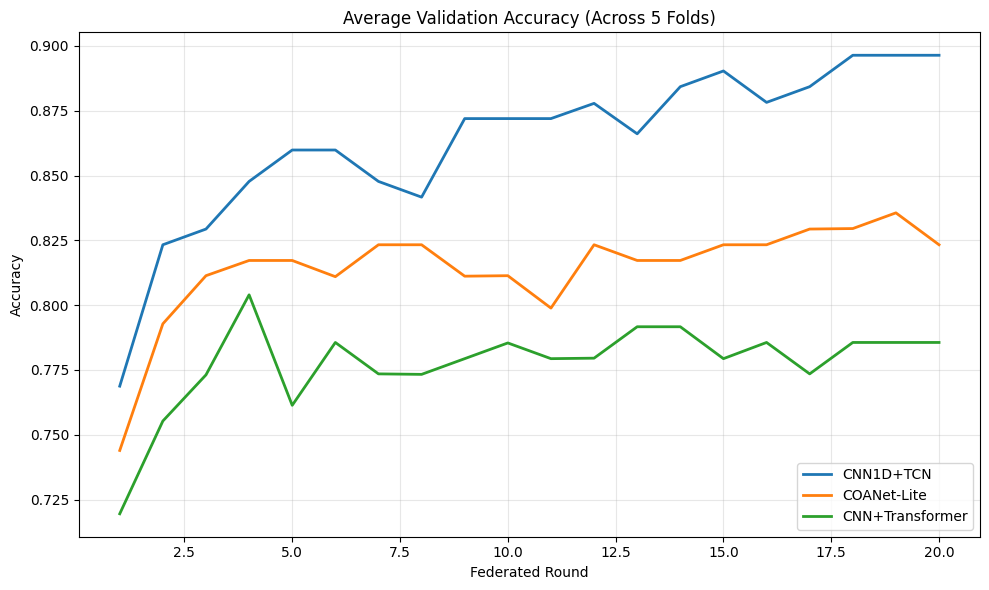

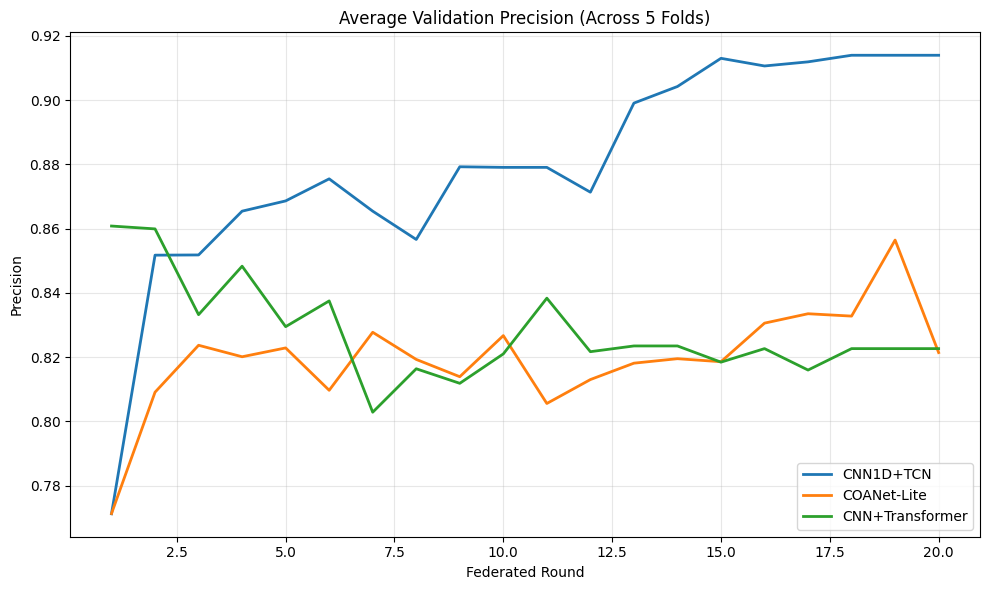

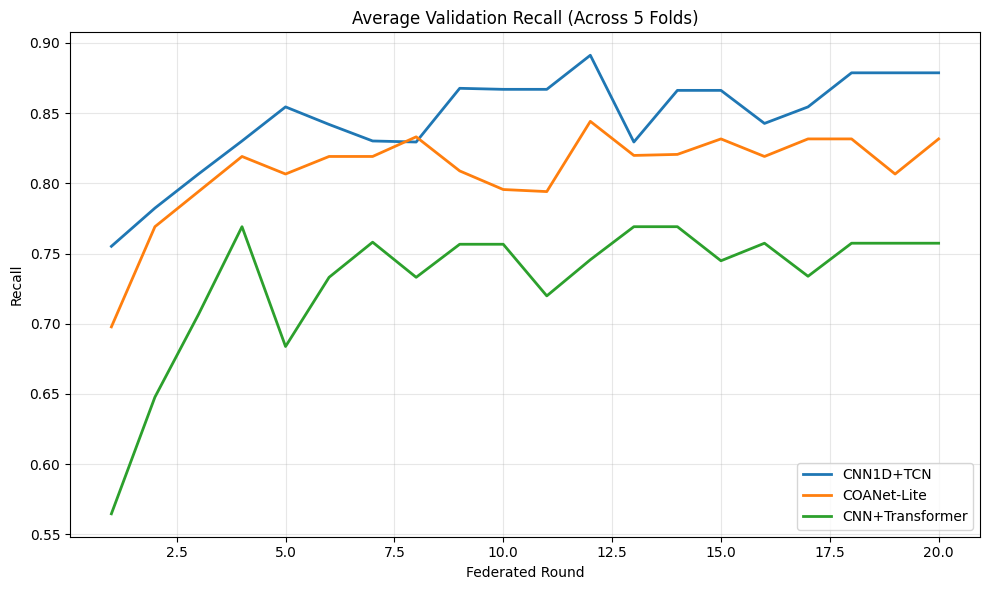

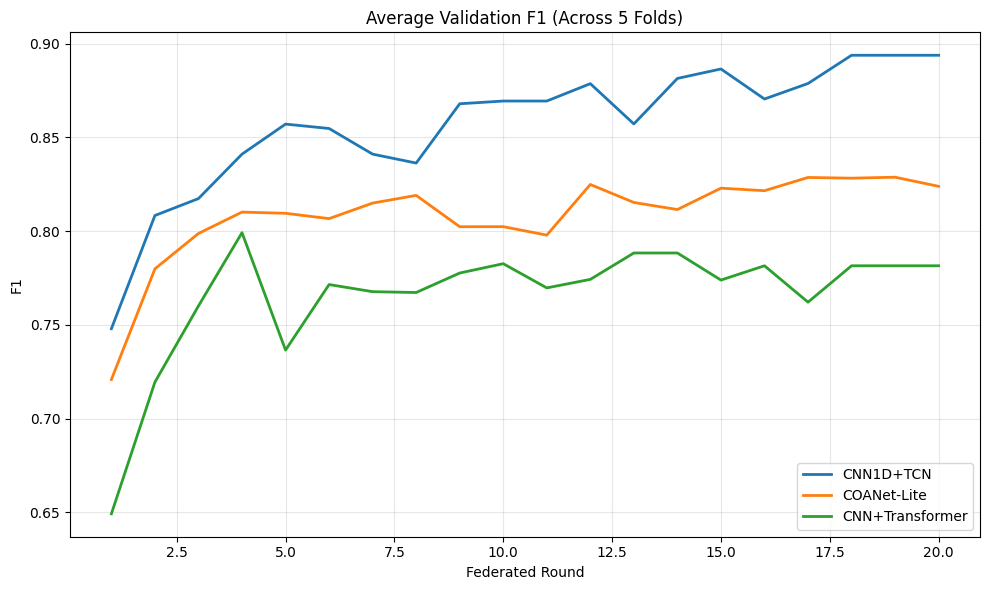

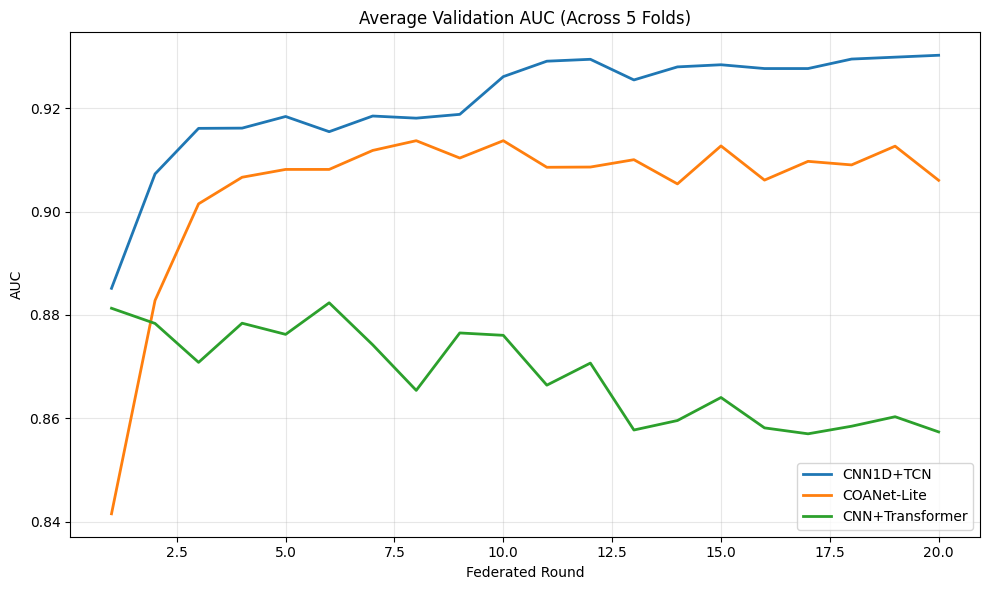


================ FINAL COMPARISON (OOF) ================

                 Accuracy  Precision  Recall     F1    AUC
CNN1D+TCN           0.896      0.911   0.878  0.894  0.929
COANet-Lite         0.823      0.819   0.829  0.824  0.906
CNN+Transformer     0.787      0.805   0.756  0.780  0.872

Generating plots...


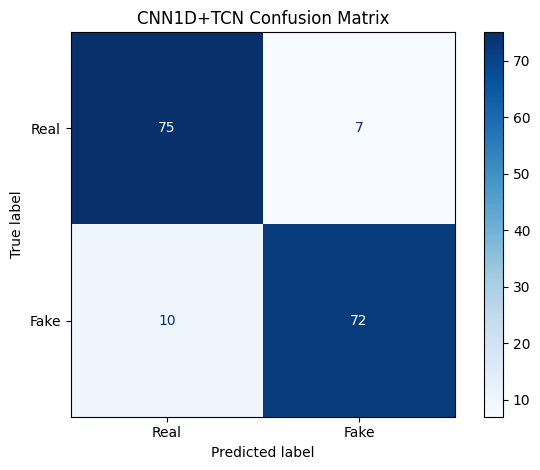

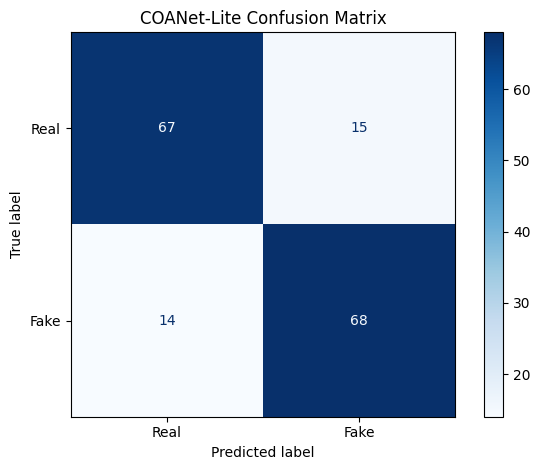

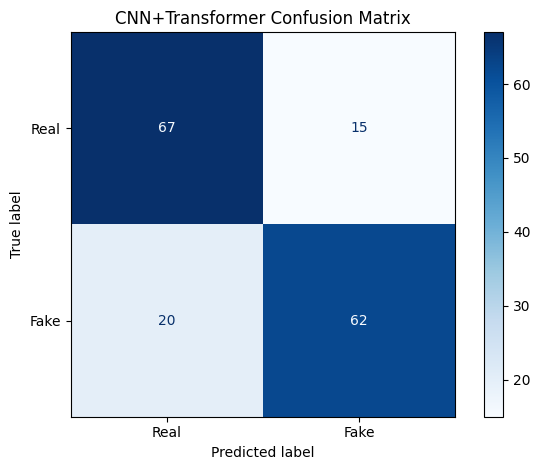

<Figure size 1400x600 with 0 Axes>

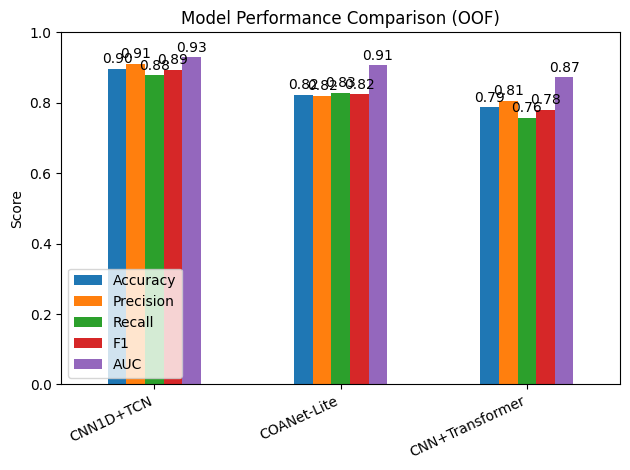

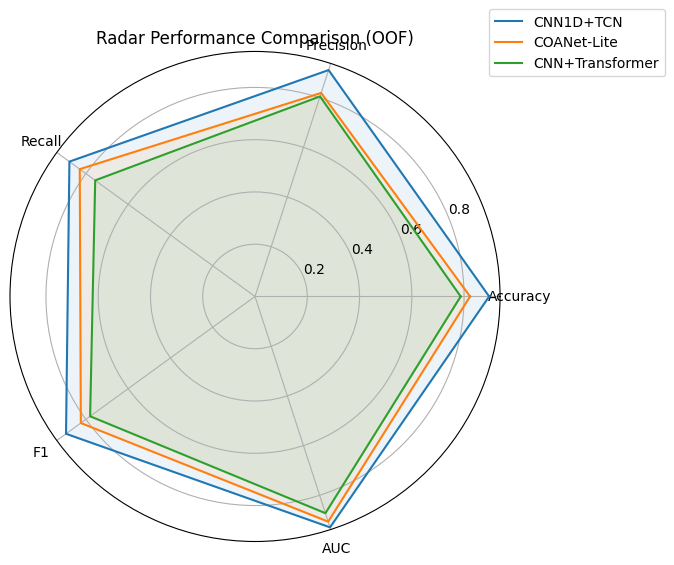

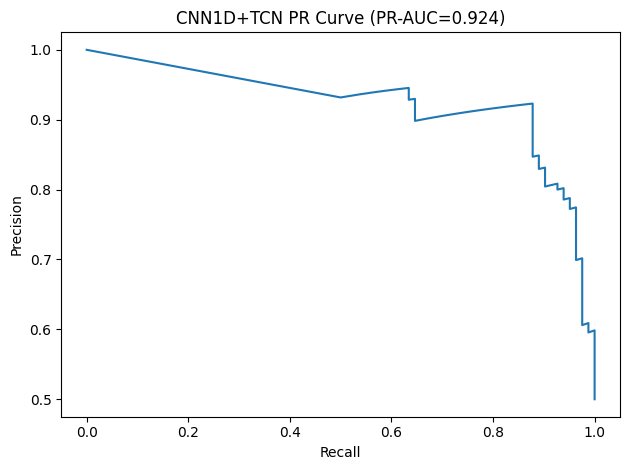

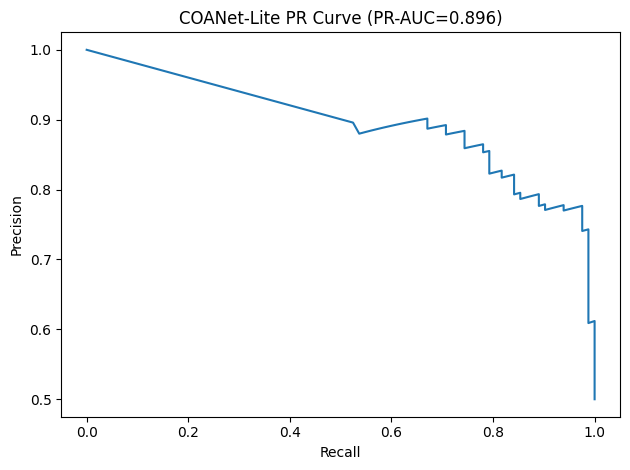

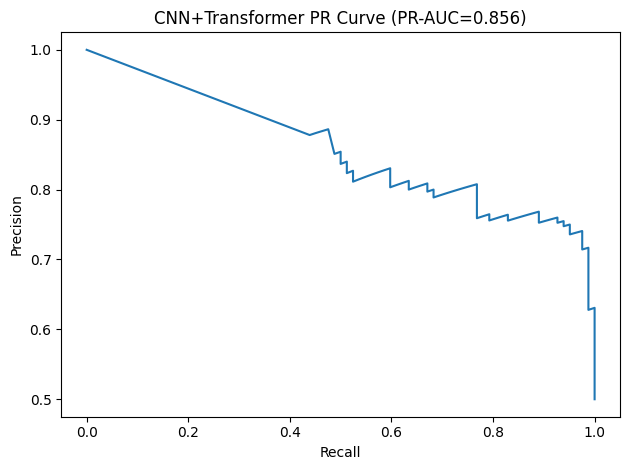

✅ All plots saved.


In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE

# -------------------------------
# DEVICE
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# -------------------------------
# PATHS
# -------------------------------
ROOT = "/content/drive/MyDrive/videos"
DATA_DIR = os.path.join(ROOT, "cnn_feature_cache_31_v1")

# -------------------------------
# CONFIG
# -------------------------------
FOLDS = 5
SEED = 42
EPOCHS = 100
BATCH_SIZE = 32
LR = 3e-4
TAB_OUT = 64
DROPOUT = 0.2
NUM_CLIENTS = 3
ROUNDS = 20
LOCAL_EPOCHS = 100

torch.manual_seed(SEED)
np.random.seed(SEED)

# ============================================================
# LOAD DATA (TABULAR + TEMPORAL)
# ============================================================
X_tab, X_seq, y = [], [], []

for fname in os.listdir(DATA_DIR):
    if not fname.endswith(".npz"):
        continue

    label = 1 if fname.lower().startswith("fake_") else 0

    with np.load(os.path.join(DATA_DIR, fname)) as d:
        seq = d["cnn_feats"]  # (T, D)
        X_seq.append(seq)

        feats = [
            seq.mean(0).reshape(-1),
            seq.std(0).reshape(-1),
            *[np.atleast_1d(d[k]).reshape(-1) for k in [
                "delta_rgb","delta_cnn","flow_mag",
                "fft_mean","fft_std","blur_mean","blur_std",
                "face_ratio_mean","face_ratio_std","lbp_mean"
            ]]
        ]
        X_tab.append(np.concatenate(feats))
        y.append(label)

X_tab = np.array(X_tab)
y = np.array(y)

print("Loaded:", len(y), "samples")
print("Class distribution:", np.bincount(y))

# ============================================================
# VISUALIZATION UTILITIES
# ============================================================
def plot_confusion(y_true, y_pred, title, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real","Fake"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(name, dpi=200)
    plt.show()
    plt.close()

def plot_bar_comparison(results_df, filename="bar_metrics_comparison.png"):
    plt.figure(figsize=(14,6))
    ax = results_df.plot(kind="bar")
    plt.title("Model Performance Comparison (OOF)")
    plt.ylabel("Score")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0,1)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()

def plot_radar(results_df, filename="radar_plot_comparison.png"):
    labels = results_df.columns.tolist()
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate((angles,[angles[0]]))

    fig = plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    for model in results_df.index:
        values = results_df.loc[model].values
        values = np.concatenate((values,[values[0]]))
        ax.plot(angles, values, label=model)
        ax.fill(angles, values, alpha=0.08)

    ax.set_thetagrids(angles[:-1]*180/np.pi, labels)
    plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))
    plt.title("Radar Performance Comparison (OOF)")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()

def plot_pr_curve(y_true, prob_scores, title, filename):
    precision, recall, _ = precision_recall_curve(y_true, prob_scores)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (PR-AUC={pr_auc:.3f})")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()


def plot_average_metrics(all_histories, metric_name, filename):
    """
    رسمة واحدة تجمع الـ 3 موديلات
    المحور الأفقي : Rounds (الـ federated rounds)
    المحور الرأسي: قيمة الـ metric
    كل خط = موديل ، الـ shading = انحراف معياري عبر الـ 5 folds
    """
    plt.figure(figsize=(10, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for (model_name, folds_data), color in zip(all_histories.items(), colors):
        data      = np.array(folds_data)        # (n_folds, ROUNDS)
        mean_vals = np.mean(data, axis=0)
        std_vals  = np.std(data,  axis=0)
        rounds_range = range(1, len(mean_vals) + 1)

        plt.plot(rounds_range, mean_vals,
                 label=f"{model_name}", color=color, lw=2)


    plt.title(f"Average Validation {metric_name} (Across {FOLDS} Folds)")
    plt.xlabel("Federated Round")
    plt.ylabel(metric_name)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    plt.close()


# ============================================================
# PREPROCESSING
# ============================================================
scaler = StandardScaler()
X_tab_scaled = scaler.fit_transform(X_tab)

sm = SMOTE(random_state=SEED)
X_tab_sm, y_sm = sm.fit_resample(X_tab_scaled, y)

print("After SMOTE:", np.bincount(y_sm))
print("X_tab_sm:", X_tab_sm.shape, "| y_sm:", len(y_sm))

# Build X_seq_sm aligned to SMOTE result
orig_n = len(X_seq)
target_n = len(y_sm)

X_seq_sm = list(X_seq)
if target_n > orig_n:
    y_orig = np.array(y)
    minority = 0 if np.sum(y_orig==0) < np.sum(y_orig==1) else 1
    minority_idx = np.where(y_orig==minority)[0]
    if len(minority_idx) == 0:
        minority_idx = np.arange(orig_n)
    extra = target_n - orig_n
    extra_idx = np.random.choice(minority_idx, size=extra, replace=True)
    for i in extra_idx:
        X_seq_sm.append(X_seq[i])

X_seq_sm = X_seq_sm[:target_n]
print("X_seq_sm:", len(X_seq_sm), "| aligned with y_sm:", len(y_sm))


# ============================================================
# SPLIT INTO CLIENTS
# ============================================================
def split_clients(X_seq_list, X_tab_arr, y_arr, num_clients=3):
    data_size = len(y_arr)
    indices = np.arange(data_size)
    np.random.shuffle(indices)
    splits = np.array_split(indices, num_clients)
    clients = []
    for idx in splits:
        clients.append((
            [X_seq_list[i] for i in idx],
            X_tab_arr[idx],
            y_arr[idx]
        ))
    return clients


# ============================================================
# DATASET
# ============================================================
class HybridDataset(Dataset):
    def __init__(self, X_seq_list, X_tab_arr, y_arr, normalize_seq=True):
        self.X_seq = X_seq_list
        self.X_tab = X_tab_arr
        self.y = y_arr
        self.normalize_seq = normalize_seq

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        seq = torch.tensor(self.X_seq[idx], dtype=torch.float32)
        if self.normalize_seq:
            seq = (seq - seq.mean(dim=0, keepdim=True)) / (seq.std(dim=0, keepdim=True) + 1e-6)
        tab = torch.tensor(self.X_tab[idx], dtype=torch.float32)
        y   = torch.tensor(self.y[idx], dtype=torch.long)
        return seq, tab, y


# ============================================================
# MODEL COMPONENTS
# ============================================================
class TabMLP(nn.Module):
    def __init__(self, tab_dim, out_dim=64, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, out_dim),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)


class HybridHead(nn.Module):
    def __init__(self, in_dim, drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)


class TemporalCNNTransformer_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(dim, hid, 3, padding=1),
            nn.ReLU()
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hid, nhead=2, dim_feedforward=hid*2,
            dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.attn = nn.Linear(hid, 1)
        self.out_dim = hid

    def forward(self, seq):
        x = seq.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        x = self.transformer(x)
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


class TemporalCNNBiLSTMAttention_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(dim, hid, 3, padding=1), nn.ReLU(),
            nn.Conv1d(hid, hid, 3, padding=1), nn.ReLU()
        )
        self.lstm = nn.LSTM(hid, hid, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(hid * 2, 1)
        self.out_dim = hid * 2

    def forward(self, seq):
        x = self.cnn(seq.transpose(1, 2)).transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        return (lstm_out * attn_weights).sum(dim=1)


class TemporalCNNTCN_Embed(nn.Module):
    def __init__(self, dim, hid=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(dim, hid, 3, padding=1),
            nn.ReLU()
        )
        self.tcn = nn.Sequential(
            nn.Conv1d(hid, hid, 3, padding=1, dilation=1), nn.ReLU(),
            nn.Conv1d(hid, hid, 3, padding=2, dilation=2), nn.ReLU()
        )
        self.out_dim = hid

    def forward(self, seq):
        x = self.cnn(seq.transpose(1, 2))
        return self.tcn(x).mean(-1)


class HybridModel(nn.Module):
    def __init__(self, temporal_backbone, tab_dim, tab_out=64, drop=0.2):
        super().__init__()
        self.temporal = temporal_backbone
        self.mlp  = TabMLP(tab_dim, out_dim=tab_out, drop=drop)
        self.head = HybridHead(self.temporal.out_dim + tab_out, drop=drop)

    def forward(self, seq, tab):
        ht = self.temporal(seq)
        hf = self.mlp(tab)
        return self.head(torch.cat([ht, hf], dim=1))


class COANetLite(nn.Module):
    def __init__(self, dim, tab_dim, hidden=128, drop=0.2):
        super().__init__()
        self.temp = nn.Sequential(
            nn.Conv1d(dim, hidden, 3, padding=1, dilation=1), nn.ReLU(),
            nn.Dropout(drop),
            nn.Conv1d(hidden, hidden, 3, padding=2, dilation=2), nn.ReLU()
        )
        self.forensic = nn.Sequential(
            nn.Linear(tab_dim, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 64), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Linear(hidden + 64, 128), nn.ReLU(),
            nn.Dropout(drop),
            nn.Linear(128, 2)
        )

    def forward(self, seq, tab):
        h_t = self.temp(seq.transpose(1, 2)).mean(-1)
        h_f = self.forensic(tab)
        return self.head(torch.cat([h_t, h_f], dim=1))


# ============================================================
# TRAIN / PREDICT / METRICS
# ============================================================
def predict_probs(model, val_loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for seq, tab, _ in val_loader:
            seq, tab = seq.to(DEVICE), tab.to(DEVICE)
            p = torch.softmax(model(seq, tab), 1)[:, 1].detach().cpu().numpy()
            probs.extend(p)
    return np.array(probs)


def calc_metrics(y_true, probs, thr=0.5):
    preds = (probs >= thr).astype(int)
    return {
        "Accuracy":  accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall":    recall_score(y_true, preds, zero_division=0),
        "F1":        f1_score(y_true, preds, zero_division=0),
        "AUC":       roc_auc_score(y_true, probs)
    }, preds


def train_one_model(model, train_loader, epochs=3, lr=3e-4):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    y_np = np.array(train_loader.dataset.y)
    classes, counts = np.unique(y_np, return_counts=True)
    w = counts.sum() / (len(classes) * counts)
    class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=5)

    for ep in range(epochs):
        model.train()
        epoch_loss = 0.0
        for seq, tab, yb in train_loader:
            seq, tab, yb = seq.to(DEVICE), tab.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(seq, tab)
            loss = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()
        epoch_loss /= max(1, len(train_loader))
        scheduler.step(epoch_loss)


# ============================================================
# FEDERATED AVERAGING
# ============================================================
def average_weights(weights_list):
    avg_weights = {}
    for key in weights_list[0].keys():
        avg_weights[key] = torch.stack(
            [w[key].float() for w in weights_list]
        ).mean(dim=0)
    return avg_weights


# ============================================================
# CV SETUP
# ============================================================
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
TAB_DIM = X_tab_sm.shape[1]

MODEL_NAMES = ["CNN1D+TCN", "COANet-Lite", "CNN+Transformer"]


def build_model(name, dim):
    if name == "CNN1D+BiLSTM+Attn":
        return HybridModel(TemporalCNNBiLSTMAttention_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    elif name == "CNN1D+TCN":
        return HybridModel(TemporalCNNTCN_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    elif name == "COANet-Lite":
        return COANetLite(dim, TAB_DIM, hidden=128, drop=DROPOUT)
    elif name == "CNN+Transformer":
        return HybridModel(TemporalCNNTransformer_Embed(dim), TAB_DIM, tab_out=TAB_OUT, drop=DROPOUT)
    else:
        raise ValueError("Unknown model")


# OOF storage
oof_probs = {m: [] for m in MODEL_NAMES}
oof_preds = {m: [] for m in MODEL_NAMES}
oof_trues = []

# ============================================================
# Metrics history عبر الـ rounds لكل موديل
# البنية: metrics_history[model_name][metric] = list of folds
#          كل fold فيها list بطول ROUNDS
# ============================================================
METRIC_KEYS = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

metrics_history = {
    m: {metric: [] for metric in METRIC_KEYS}
    for m in MODEL_NAMES
}

# ============================================================
# RUN CV + FEDERATED LEARNING (داخل كل fold)
# ============================================================
for fold, (train_idx, val_idx) in enumerate(skf.split(X_tab_sm, y_sm), 1):
    print(f"\n========== FOLD {fold}/{FOLDS} ==========")

    Xtr_tab, Xval_tab = X_tab_sm[train_idx], X_tab_sm[val_idx]
    ytr, yval         = y_sm[train_idx], y_sm[val_idx]

    Xtr_seq  = [X_seq_sm[i] for i in train_idx]
    Xval_seq = [X_seq_sm[i] for i in val_idx]

    val_loader = DataLoader(
        HybridDataset(Xval_seq, Xval_tab, yval),
        batch_size=BATCH_SIZE, shuffle=False
    )

    dim = Xtr_seq[0].shape[1]
    oof_trues.extend(yval.tolist())

    clients_data_fold = split_clients(Xtr_seq, Xtr_tab, ytr, NUM_CLIENTS)
    print(f"Number of clients: {len(clients_data_fold)}")

    for name in MODEL_NAMES:
        print(f"\n  >> Model: {name}")

        global_model = build_model(name, dim).to(DEVICE)

        # قوائم مؤقتة لهذا الـ fold × هذا الـ model
        fold_round_metrics = {metric: [] for metric in METRIC_KEYS}

        for rnd in range(ROUNDS):
            client_weights = []

            for client_id, (c_seq, c_tab, c_y) in enumerate(clients_data_fold):
                local_model = build_model(name, dim).to(DEVICE)
                local_model.load_state_dict(global_model.state_dict())

                loader = DataLoader(
                    HybridDataset(c_seq, c_tab, c_y),
                    batch_size=BATCH_SIZE, shuffle=True
                )

                train_one_model(local_model, loader, epochs=LOCAL_EPOCHS, lr=LR)
                client_weights.append(local_model.state_dict())

            # Federated averaging
            global_model.load_state_dict(average_weights(client_weights))

            # تقييم بعد كل round وحفظ الـ metrics
            probs_rnd = predict_probs(global_model, val_loader)
            mets_rnd, _ = calc_metrics(yval, probs_rnd, thr=0.5)

            for metric in METRIC_KEYS:
                fold_round_metrics[metric].append(mets_rnd[metric])

            print(
                f"Round {rnd+1}/{ROUNDS} | "
                f"Acc={mets_rnd['Accuracy']:.3f} | "
                f"Prec={mets_rnd['Precision']:.3f} | "
                f"Rec={mets_rnd['Recall']:.3f} | "
                f"F1={mets_rnd['F1']:.3f} | "
                f"AUC={mets_rnd['AUC']:.3f}"
            )

        # حفظ قيم الـ rounds لهذا الـ fold في التاريخ الكلي
        for metric in METRIC_KEYS:
            metrics_history[name][metric].append(fold_round_metrics[metric])

        # النتيجة النهائية (آخر round)
        final_probs = predict_probs(global_model, val_loader)
        torch.save(global_model.state_dict(), f"{name}_model.pth")
        print(f"Saved model: {name}")

        _, final_preds = calc_metrics(yval, final_probs, thr=0.5)
        oof_probs[name].extend(final_probs.tolist())
        oof_preds[name].extend(final_preds.tolist())


# ============================================================
# METRICS CURVES — رسمة لكل metric تجمع الـ 3 موديلات
# المحور الأفقي: Federated Rounds (1 → 20)
# ============================================================
print("\nGenerating average metrics curves across rounds...")

for metric in METRIC_KEYS:
    all_histories = {
        name: metrics_history[name][metric]   # list of 5 folds، كل fold = 20 قيمة
        for name in MODEL_NAMES
    }
    safe_metric = metric.replace(" ", "_")
    plot_average_metrics(
        all_histories,
        metric_name=metric,
        filename=f"avg_val_{safe_metric}_all_models.png"
    )


# ============================================================
# FINAL RESULTS (OOF)
# ============================================================
oof_trues = np.array(oof_trues)

final_rows = {}
for name in MODEL_NAMES:
    probs = np.array(oof_probs[name])
    mets, _ = calc_metrics(oof_trues, probs, thr=0.5)
    final_rows[name] = mets

results = pd.DataFrame(final_rows).T.round(3)
print("\n================ FINAL COMPARISON (OOF) ================\n")
print(results)

# ============================================================
# PLOTS
# ============================================================
print("\nGenerating plots...")

for name in MODEL_NAMES:
    preds = np.array(oof_preds[name])
    plot_confusion(
        oof_trues, preds,
        f"{name} Confusion Matrix",
        f"confusion_matrix_{name.replace('+','_').replace(' ','_')}.png"
    )

plot_bar_comparison(results, filename="bar_metrics_comparison.png")
plot_radar(results, filename="radar_plot_comparison.png")

for name in MODEL_NAMES:
    probs = np.array(oof_probs[name])
    plot_pr_curve(
        oof_trues, probs,
        f"{name} PR Curve",
        f"pr_curve_{name.replace('+','_').replace(' ','_')}.png"
    )

print("✅ All plots saved.")


... Initializing Grad-CAM for CNN1D+TCN ...
Model loaded successfully.
Targeting layer for Grad-CAM: Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))

Generating Grad-CAM for sample 8 (Label: Fake)...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


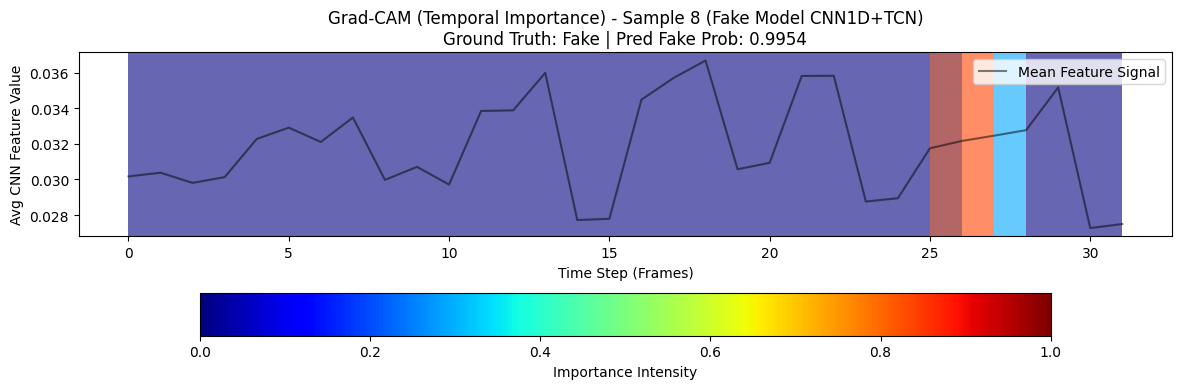

In [ ]:
# ============================================================
# خليه جديدة: إعدادات GRAD-CAM لنماذج الـ 1D
# ============================================================
import torch.nn.functional as F

class GradCAM1D:
    """
    Grad-CAM implementation for 1D Temporal CNN models
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.model.eval()
        self._register_hooks()

    def _register_hooks(self):
        # Hook for forward pass to save activations
        def forward_hook(module, input, output):
            self.activations = output.detach()
            # print(f"Registered Forward Hook. Shape: {self.activations.shape}")

        # Hook for backward pass to save gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
            # print(f"Registered Backward Hook. Shape: {self.gradients.shape}")

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_heatmap(self, seq_input, tab_input, class_idx=1):
        """
        Generates Grad-CAM heatmap for 1D sequence
        """
        # zero grads
        self.model.zero_grad()

        # Forward pass
        logits = self.model(seq_input, tab_input)

        # Target for backprop (score for the specific class)
        score = logits[:, class_idx]

        # Backward pass
        score.backward(retain_graph=True)

        # Grad-CAM logic
        # 1. Pool gradients across temporal dimension (avg) to get weights
        weights = torch.mean(self.gradients, dim=2, keepdim=True) # (B, C, 1)

        # 2. Weighted combination of activation maps
        cam = torch.sum(weights * self.activations, dim=1).squeeze() # (B, T)

        # 3. Apply ReLU (we only care about features that have a positive influence)
        cam = np.maximum(cam.cpu().numpy(), 0)

        # Normalize between 0-1
        if cam.max() != cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam, logits.detach().cpu()


def plot_gradcam_1d(original_seq, heatmap, title, pred_probs, label):
    """
    Plots the 1D feature importance (heatmap) over time
    """
    T, D = original_seq.shape
    # Plot feature mean as representative signal
    signal = original_seq.mean(axis=1)

    fig, ax = plt.subplots(figsize=(12, 4))

    # Plot the "signal" (mean CNN feature over time)
    time_steps = np.arange(T)
    ax.plot(time_steps, signal, color='black', alpha=0.5, label='Mean Feature Signal')

    # Map heatmap values to colors
    # Use 'jet' colormap for standard Grad-CAM style
    cmap = plt.get_cmap('jet')

    # Fill background colors based on heatmap importance
    for t in range(T-1):
        color = cmap(heatmap[t])
        ax.axvspan(t, t+1, color=color, alpha=0.6, ec=None)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.2)
    cbar.set_label('Importance Intensity')

    gt = "Fake" if label == 1 else "Real"
    pred_fake = pred_probs[1].item()

    plt.title(f"Grad-CAM (Temporal Importance) - {title}\n"
              f"Ground Truth: {gt} | Pred Fake Prob: {pred_fake:.4f}")
    plt.xlabel("Time Step (Frames)")
    plt.ylabel("Avg CNN Feature Value")
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# ============================================================
# خليه جديدة: تشغيل GRAD-CAM على أفضل موديل (CNN1D+TCN)
# ============================================================
print("\n... Initializing Grad-CAM for CNN1D+TCN ...")

# 1. إعادة بناء الموديل (تأكدي من توفر TAB_DIM و TAB_OUT في الـ workspace)
dim = X_seq_sm[0].shape[1] # Dimension of CNN features
best_model_name = "CNN1D+TCN"
model_gradcam = build_model(best_model_name, dim)

# 2. تحميل الأوزان (يجب أن يكون الملف موجود في المجلد)
model_path = f"{best_model_name}_model.pth"
if os.path.exists(model_path):
    model_gradcam.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model_gradcam.to(DEVICE)
    print("Model loaded successfully.")
else:
    print(f"Error: Could not find model weights at {model_path}")

# 3. تحديد الطبقة التلافيفية المستهدفة (آخر Conv layer في الـ TCN)
# في الهيكل حقنا: model.temporal is TemporalCNNTCN_Embed
# model.temporal.tcn contains: Conv1d(dil1), ReLU, Conv1d(dil2), ReLU
# نستهدف آخر conv layer (الاندكس 2)
target_layer = model_gradcam.temporal.tcn[2]
print(f"Targeting layer for Grad-CAM: {target_layer}")

# 4. إعداد Grad-CAM
gcam = GradCAM1D(model_gradcam, target_layer)

# 5. اختيار عينة واحدة من الـ Validation Set (مثلاً أول فيديو مزيف)
# نحتاج Dataset غير الـ loader لسهولة التعامل
full_val_dataset = HybridDataset(Xval_seq, Xval_tab, yval, normalize_seq=True)

# البحث عن أول مؤشر (index) لفيديو مزيف في بيانات التحقق
target_idx = None
for i in range(len(yval)):
    if yval[i] == 1: # Fake
        target_idx = i
        break

if target_idx is not None:
    print(f"\nGenerating Grad-CAM for sample {target_idx} (Label: Fake)...")
    seq_tensor, tab_tensor, label_tensor = full_val_dataset[target_idx]

    # إضافة batch dimension (B=1)
    seq_in = seq_tensor.unsqueeze(0).to(DEVICE)
    tab_in = tab_tensor.unsqueeze(0).to(DEVICE)

    # توليد الخريطة الحرارية (Heatmap)
    heatmap, logits = gcam.generate_heatmap(seq_in, tab_in, class_idx=1)
    probs = F.softmax(logits, dim=1).squeeze()

    # الحصول على البيانات الأصلية للرسم (غير المنملزة)
    orig_seq = Xval_seq[target_idx]

    # الرسم
    plot_gradcam_1d(
        orig_seq, heatmap,
        title=f"Sample {target_idx} (Fake Model {best_model_name})",
        pred_probs=probs, label=yval[target_idx]
    )
else:
    print("No Fake sample found in validation set to visualize.")

In [ ]:
def measure_latency(model_name, dataset, num_samples=50):
    model = build_model(model_name, dim).to(DEVICE)

    model_path = f"{model_name}_model.pth"
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    model.eval()
    latencies = []

    print(f"Measuring latency for {model_name}...")

    # -------------------
    # Warm-up
    # -------------------
    with torch.no_grad():
        for _ in range(10):
            seq, tab, _ = dataset[0]
            seq = seq.unsqueeze(0).to(DEVICE)
            tab = tab.unsqueeze(0).to(DEVICE)
            _ = model(seq, tab)

    # -------------------
    # Actual measurement
    # -------------------
    with torch.no_grad():
        for i in range(min(num_samples, len(dataset))):
            seq, tab, _ = dataset[i]
            seq = seq.unsqueeze(0).to(DEVICE)
            tab = tab.unsqueeze(0).to(DEVICE)

            if DEVICE == "cuda":
                torch.cuda.synchronize()

            start_time = time.perf_counter()

            _ = model(seq, tab)

            if DEVICE == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            latencies.append(end_time - start_time)

    # تجاهل أول كم قياس
    latencies = latencies[5:]

    avg_latency = np.mean(latencies) * 1000
    std_latency = np.std(latencies) * 1000

    return avg_latency, std_latency

In [ ]:
import time # ضروري لعمل دالة perf_counter
latency_results = {}
val_dataset = HybridDataset(Xval_seq, Xval_tab, yval)

for name in MODEL_NAMES:
    avg_l, std_l = measure_latency(name, val_dataset)
    latency_results[name] = {
        "Avg Latency (ms)": avg_l,
        "Std Dev (ms)": std_l
    }

latency_df = pd.DataFrame(latency_results).T.round(3)

print("\n================ LATENCY REPORT ================\n")
print(latency_df)

Measuring latency for CNN1D+TCN...
Measuring latency for COANet-Lite...
Measuring latency for CNN+Transformer...

================ LATENCY REPORT ================

                 Avg Latency (ms)  Std Dev (ms)
CNN1D+TCN                   1.199         0.122
COANet-Lite                 1.089         0.124
CNN+Transformer             2.573         1.618
